In [1]:
import requests
import pandas as pd
import numpy as np

**Get data**

In [2]:
def get_blockchain_metrics(chart, start_date, end_date):
    url = f"https://api.blockchain.info/charts/{chart}"

    params = {
        "format": "json",
        "sampled": "false",
        "timespan": "3685days"
    }
    
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()["values"]
    
    df = pd.DataFrame(data)
    df["date"] = pd.to_datetime(df["x"], unit="s")
    df = df.set_index("date")[["y"]].rename(columns={"y": chart})
    df = df.sort_index()

    start = pd.to_datetime(start_date, format="%d-%m-%Y")
    end = pd.to_datetime(end_date, format="%d-%m-%Y")

    df = df.loc[start:end]
    df = df.resample("D").mean()
    return df

In [3]:
start = "31-01-2016"
end = "01-02-2026"

metrics = [
    "n-transactions", # measures activity, number of daily transactions
    "transaction-fees-usd", # in usd
    "n-unique-addresses", # measures activity
    "mempool-count", # measures congestion, from their website: The mempool is where all valid transactions wait to be confirmed by the Bitcoin network. A high number of transactions in the mempool indicates a congested traffic which will result in longer average confirmation time and higher priority fees
    "estimated-transaction-volume-usd",
    "median-confirmation-time", # measures congestion, The median time for a transaction with miner fees to be included in a mined block and added to the public ledger.
    "hash-rate",
    "difficulty"
]

In [4]:
dfs = [get_blockchain_metrics(metric, start, end) for metric in metrics]

In [5]:
blockchain_data = pd.concat(dfs, axis=1)
print(blockchain_data)

            n-transactions  transaction-fees-usd  n-unique-addresses  \
date                                                                   
2016-01-31        176045.0          13503.945171            402413.0   
2016-02-01        222398.0          21477.202799            410364.0   
2016-02-02        241722.0          23939.155147            488072.0   
2016-02-03        191224.0          17911.280651            368096.0   
2016-02-04        200661.0          15305.126482            392766.0   
...                    ...                   ...                 ...   
2026-01-28        336095.0         267126.145026            485652.0   
2026-01-29        428725.0         260550.655850            521611.0   
2026-01-30        380796.0         279086.868528            580888.0   
2026-01-31        405402.0         264980.537317            527605.0   
2026-02-01        352779.0         208415.619079            467476.0   

            mempool-count  estimated-transaction-volume-usd  \


In [6]:
# summary statistics
blockchain_data.describe()

,n-transactions,transaction-fees-usd,n-unique-addresses,mempool-count,estimated-transaction-volume-usd,median-confirmation-time,hash-rate,difficulty
count,3652.000000,3.655000e+03,3.649000e+03,3520.000000,3.647000e+03,3652.000000,3.652000e+03,3.652000e+03
mean,327484.532585,1.209454e+06,5.705330e+05,36840.743491,3.535001e+09,9.399255,2.615989e+08,3.616804e+13
std,117885.076079,2.651030e+06,1.197093e+05,55963.575349,4.163873e+09,3.162022,3.038235e+08,4.194833e+13
min,124640.000000,1.335829e+04,3.011320e+05,918.677083,7.625467e+07,0.058333,9.785699e+05,1.200333e+11
25%,250742.750000,2.169982e+05,4.804840e+05,3789.648438,7.786187e+08,7.333333,3.856664e+07,5.363678e+12
50%,296843.000000,4.709099e+05,5.586870e+05,8262.539062,1.946783e+09,8.925000,1.334000e+08,1.867017e+13
75%,365091.500000,9.882749e+05,6.583580e+05,40836.320312,4.800363e+09,10.900000,3.918433e+08,5.239118e+13
max,927010.000000,8.105034e+07,1.072862e+06,300519.588542,5.838867e+10,29.250000,1.305500e+09,1.559730e+14


array([<Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>], dtype=object)

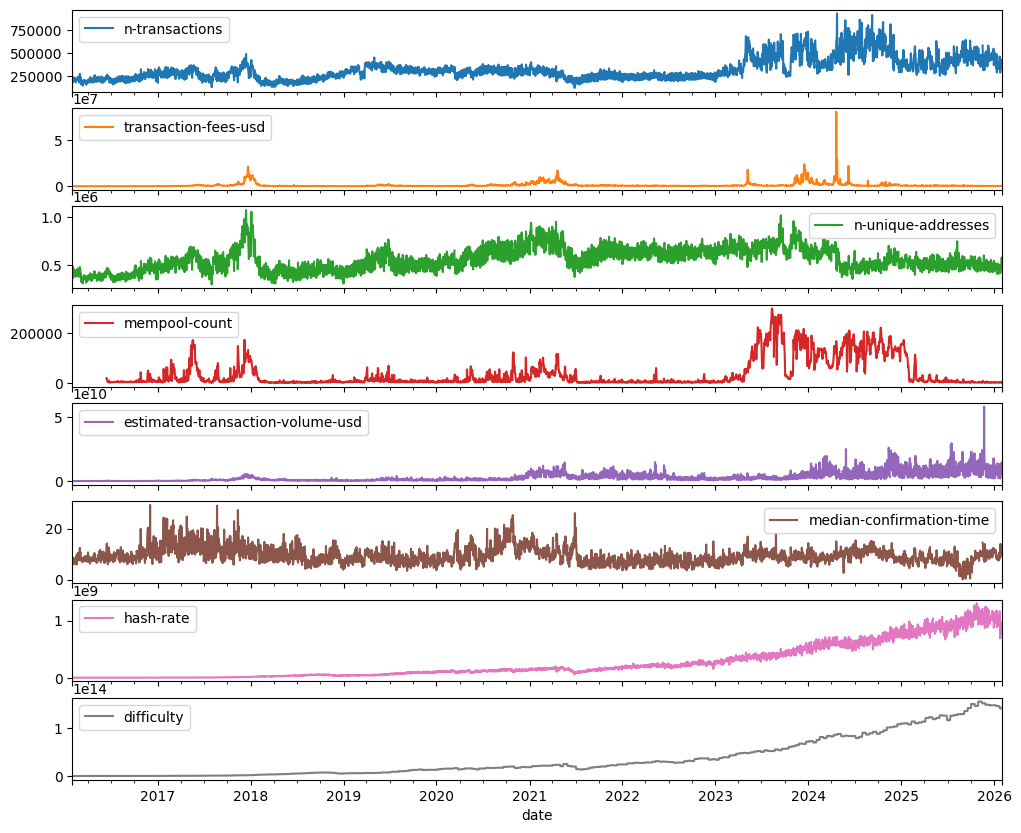

In [7]:
# trend
blockchain_data.plot(subplots=True, figsize=(12,10))

In [8]:
# correlation
blockchain_data.corr()

,n-transactions,transaction-fees-usd,n-unique-addresses,mempool-count,estimated-transaction-volume-usd,median-confirmation-time,hash-rate,difficulty
n-transactions,1.000000,0.264826,0.236792,0.644465,0.443461,0.041252,0.662907,0.640077
transaction-fees-usd,0.264826,1.000000,0.369074,0.358070,0.173716,0.158769,0.062598,0.062097
n-unique-addresses,0.236792,0.369074,1.000000,0.265843,0.269422,0.110123,0.062601,0.053148
mempool-count,0.644465,0.358070,0.265843,1.000000,0.241975,0.204425,0.312705,0.314512
estimated-transaction-volume-usd,0.443461,0.173716,0.269422,0.241975,1.000000,-0.095021,0.718079,0.724580
median-confirmation-time,0.041252,0.158769,0.110123,0.204425,-0.095021,1.000000,-0.205356,-0.173587
hash-rate,0.662907,0.062598,0.062601,0.312705,0.718079,-0.205356,1.000000,0.992339
difficulty,0.640077,0.062097,0.053148,0.314512,0.724580,-0.173587,0.992339,1.000000


In [9]:
# check na
blockchain_data.isna().sum()

n-transactions                        3
transaction-fees-usd                  0
n-unique-addresses                    6
mempool-count                       135
estimated-transaction-volume-usd      8
median-confirmation-time              3
hash-rate                             3
difficulty                            3
dtype: int64

In [10]:
blockchain_data[blockchain_data.isna().any(axis=1)]

,n-transactions,transaction-fees-usd,n-unique-addresses,mempool-count,estimated-transaction-volume-usd,median-confirmation-time,hash-rate,difficulty
date,,,,,,,,
2016-01-31,176045.0,1.350395e+04,402413.0,NaN,1.036659e+08,6.816667,1.068073e+06,1.200333e+11
2016-02-01,222398.0,2.147720e+04,410364.0,NaN,1.868384e+08,8.550000,1.050173e+06,1.200333e+11
2016-02-02,241722.0,2.393916e+04,488072.0,NaN,1.681395e+08,8.666667,9.785699e+05,1.200333e+11
2016-02-03,191224.0,1.791128e+04,368096.0,NaN,1.157640e+08,7.483333,1.038239e+06,1.200333e+11
2016-02-04,200661.0,1.530513e+04,392766.0,NaN,1.458508e+08,6.883333,1.103875e+06,1.200333e+11
...,...,...,...,...,...,...,...,...
2024-11-18,673308.0,1.594459e+06,569926.0,181241.020833,NaN,9.091667,7.891775e+08,1.017663e+14
2025-06-24,279124.0,6.503038e+05,498971.0,23100.260417,NaN,9.208333,7.352218e+08,1.264114e+14
2025-11-13,NaN,3.015790e+05,NaN,2872.927083,1.308801e+10,NaN,NaN,NaN


In [11]:
# forward fill the columns except mempool-count
cols = blockchain_data.columns.difference(["mempool-count"])
blockchain_data[cols] = blockchain_data[cols].ffill()

blockchain_data.isna().sum()

n-transactions                        0
transaction-fees-usd                  0
n-unique-addresses                    0
mempool-count                       135
estimated-transaction-volume-usd      0
median-confirmation-time              0
hash-rate                             0
difficulty                            0
dtype: int64

array([[<Axes: title={'center': 'n-transactions'}>,
        <Axes: title={'center': 'transaction-fees-usd'}>,
        <Axes: title={'center': 'n-unique-addresses'}>],
       [<Axes: title={'center': 'mempool-count'}>,
        <Axes: title={'center': 'estimated-transaction-volume-usd'}>,
        <Axes: title={'center': 'median-confirmation-time'}>],
       [<Axes: title={'center': 'hash-rate'}>,
        <Axes: title={'center': 'difficulty'}>, <Axes: >]], dtype=object)

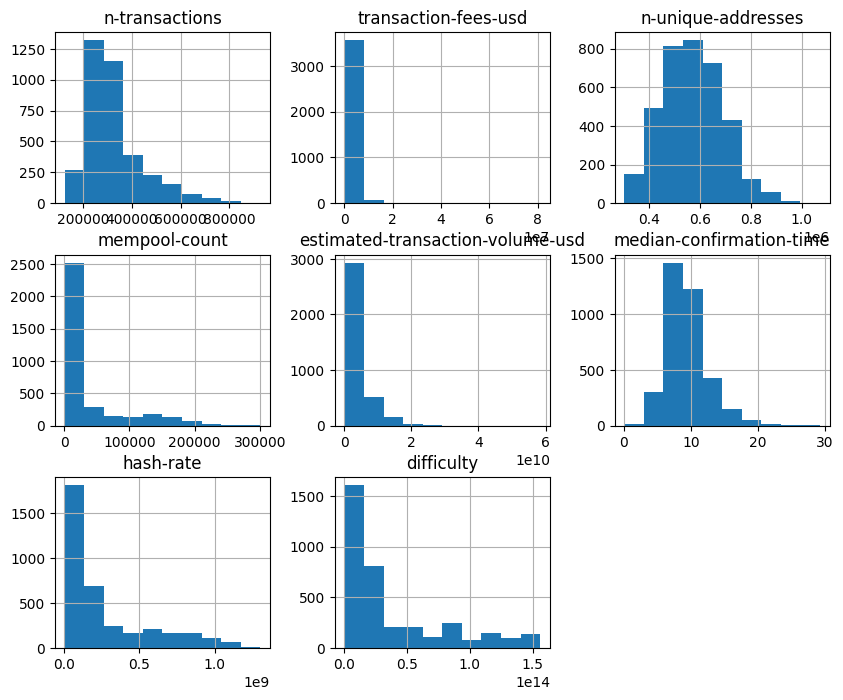

In [12]:
blockchain_data.hist(figsize=(10,8))

In [13]:
# log transformation
blockchain_data["blockchain_log_n_transactions"] = np.log(blockchain_data["n-transactions"])
blockchain_data["blockchain_log_transaction_fee_usd"] = np.log(blockchain_data["transaction-fees-usd"] + 1) # +1 bcos can be zero
blockchain_data["blockchain_log_n_unique_addresses"] = np.log(blockchain_data["n-unique-addresses"])
blockchain_data["blockchain_log_mempool_count"] = np.log(blockchain_data["mempool-count"] + 1) # +1 bcos can be zero
blockchain_data["blockchain_log_transaction_volume+usd"] = np.log(blockchain_data["estimated-transaction-volume-usd"])

array([[<Axes: title={'center': 'n-transactions'}>,
        <Axes: title={'center': 'transaction-fees-usd'}>,
        <Axes: title={'center': 'n-unique-addresses'}>,
        <Axes: title={'center': 'mempool-count'}>],
       [<Axes: title={'center': 'estimated-transaction-volume-usd'}>,
        <Axes: title={'center': 'median-confirmation-time'}>,
        <Axes: title={'center': 'hash-rate'}>,
        <Axes: title={'center': 'difficulty'}>],
       [<Axes: title={'center': 'blockchain_log_n_transactions'}>,
        <Axes: title={'center': 'blockchain_log_transaction_fee_usd'}>,
        <Axes: title={'center': 'blockchain_log_n_unique_addresses'}>,
        <Axes: title={'center': 'blockchain_log_mempool_count'}>],
       [<Axes: title={'center': 'blockchain_log_transaction_volume+usd'}>,
        <Axes: >, <Axes: >, <Axes: >]], dtype=object)

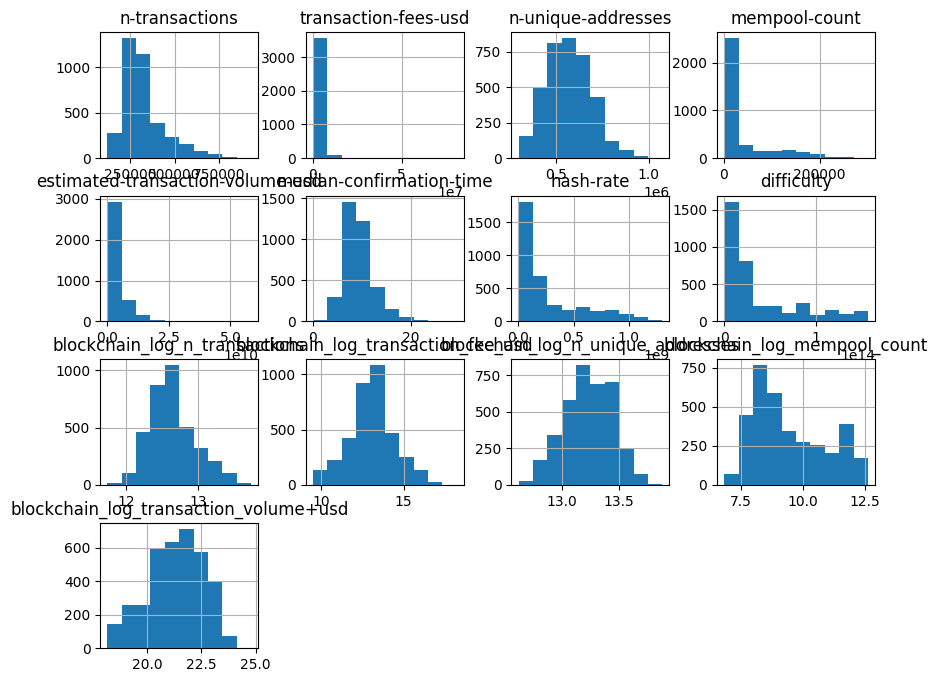

In [14]:
blockchain_data.hist(figsize=(10,8))

In [18]:
# take first difference
blockchain_data["blockchain_diff_log_n_transactions"] = blockchain_data["blockchain_log_n_transactions"].diff()
blockchain_data["blockchain_diff_log_transaction_fee_usd"] = blockchain_data["blockchain_log_transaction_fee_usd"].diff()
blockchain_data["blockchain_diff_log_n_unique_addresses"] = blockchain_data["blockchain_log_n_unique_addresses"].diff()
blockchain_data["blockchain_diff_log_transaction_volume_usd"] = blockchain_data["blockchain_log_transaction_volume+usd"].diff()

In [19]:
blockchain_data.isna().sum()

n-transactions                                  0
transaction-fees-usd                            0
n-unique-addresses                              0
mempool-count                                 135
estimated-transaction-volume-usd                0
median-confirmation-time                        0
hash-rate                                       0
difficulty                                      0
blockchain_log_n_transactions                   0
blockchain_log_transaction_fee_usd              0
blockchain_log_n_unique_addresses               0
blockchain_log_mempool_count                  135
blockchain_log_transaction_volume+usd           0
blockchain_diff_log_n_transactions              1
blockchain_diff_log_transaction_fee_usd         1
blockchain_diff_log_n_unique_addresses          1
blockchain_diff_log_transaction_volume_usd      1
dtype: int64

In [20]:
blockchain_data.to_csv("blockchain_data.csv")